# Library

In [6]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Data

In [7]:
df = pd.read_csv('london_merged.csv')

# ambil hanya kolom timestamp dan cnt (count)
df = df[['timestamp', 'cnt']]
df['timestamp'] = pd.to_datetime(df['timestamp'])

# agregasi data menjadi perhari dengan sum
df = df.groupby(df['timestamp'].dt.date)['cnt'].sum().reset_index()
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

# urutakan data dari yang terlama
df = df.sort_values('ds').reset_index(drop=True)

df.head()

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      730 non-null    datetime64[ns]
 1   y       730 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 11.5 KB


In [9]:
# cek missing value
print(df.isnull().sum())

ds    0
y     0
dtype: int64


# Eksplorasi Data

## Plot Time Series

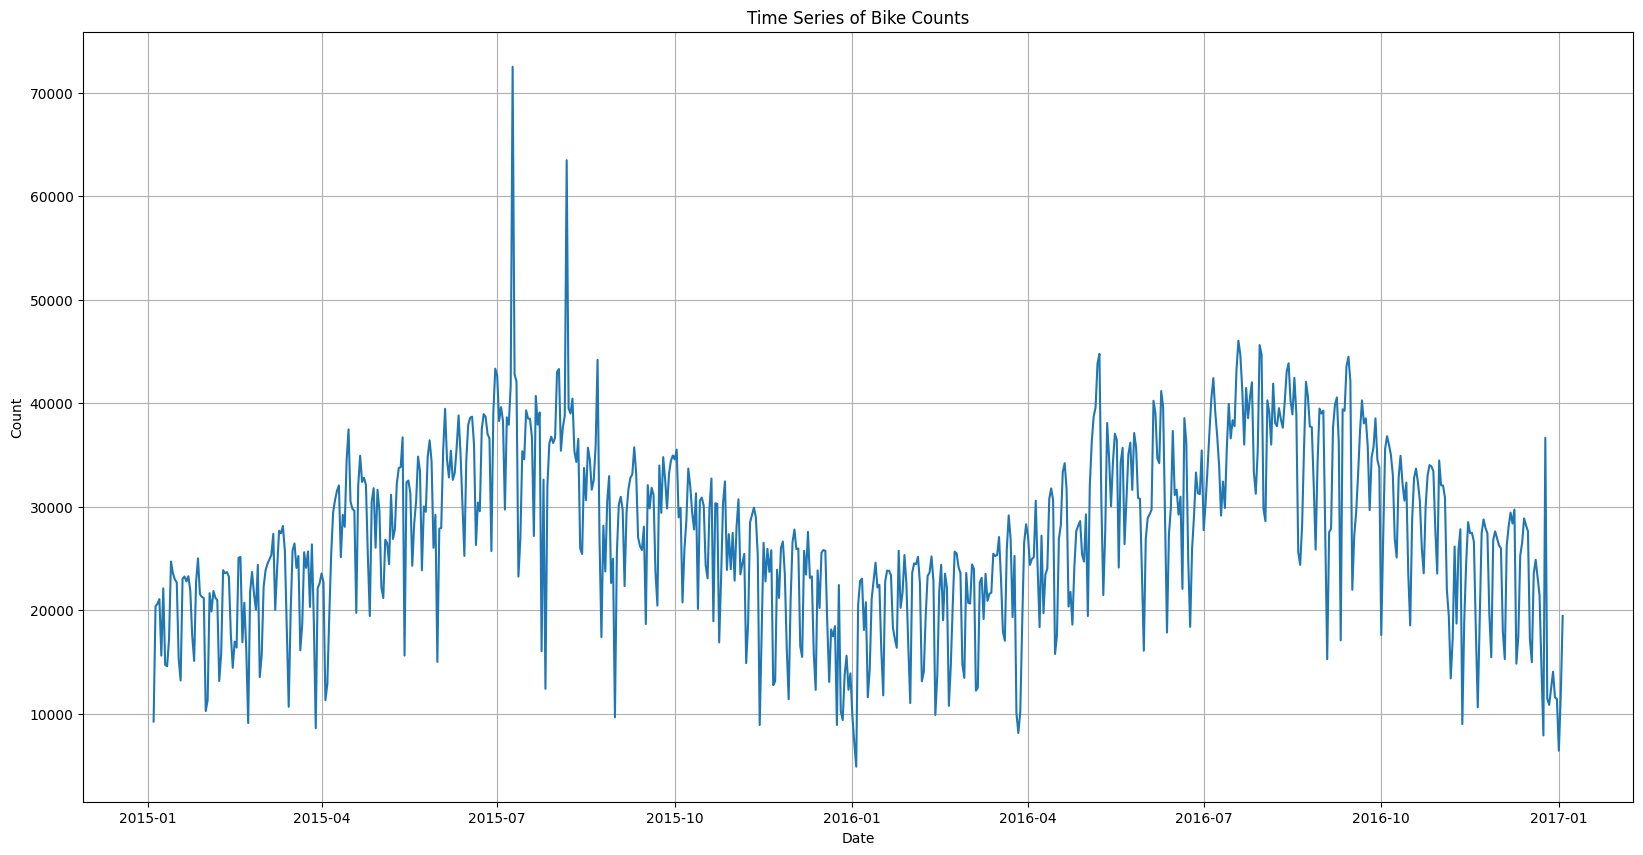

In [10]:
# Plot time series of levels
plt.figure(figsize=(20, 10))
plt.plot(df['ds'], df['y'])
plt.title('Time Series of Bike Counts')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)

## Plot Rata-rata Harian

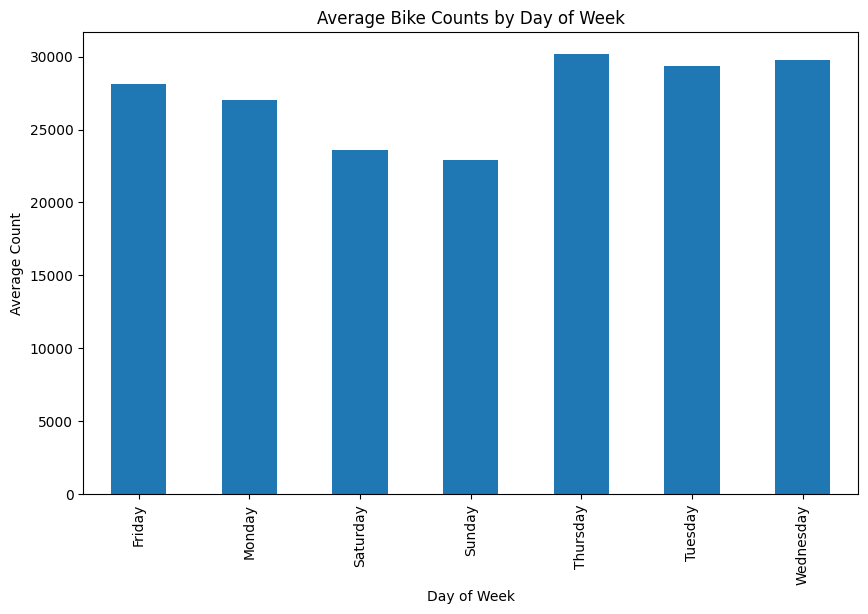

In [11]:
# Plot rata-rata per hari dalam seminggu untuk melihat pola
df['day_of_week'] = df['ds'].dt.day_name()
mean_by_day = df.groupby('day_of_week')['y'].mean()
plt.figure(figsize=(10, 6))
mean_by_day.plot(kind='bar')
plt.title('Average Bike Counts by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Count')
plt.show()

## Plot Rata-rata Bulanan

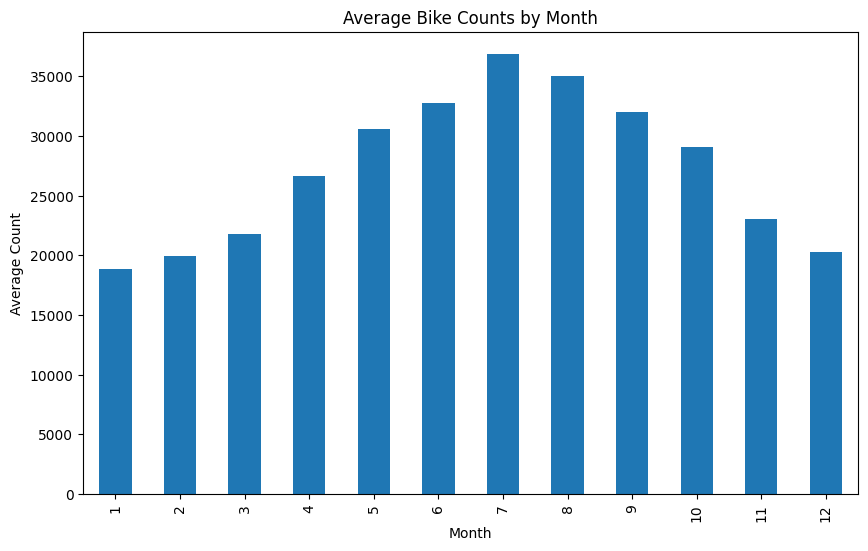

In [12]:
# Plot rata-rata per bulan
df['month'] = df['ds'].dt.month
mean_by_month = df.groupby('month')['y'].mean()

plt.figure(figsize=(10, 6))
mean_by_month.plot(kind='bar')
plt.title('Average Bike Counts by Month')
plt.xlabel('Month')
plt.ylabel('Average Count')
plt.show()

# Modelling Prophet

## Splitting Data

In [13]:
# Split data: 80% train, 20% test
train_size = int(0.8 * len(df))
train = df[:train_size]
test = df[train_size:]
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')

Train shape: (584, 4)
Test shape: (146, 4)


### Visualisasi Splitting Data

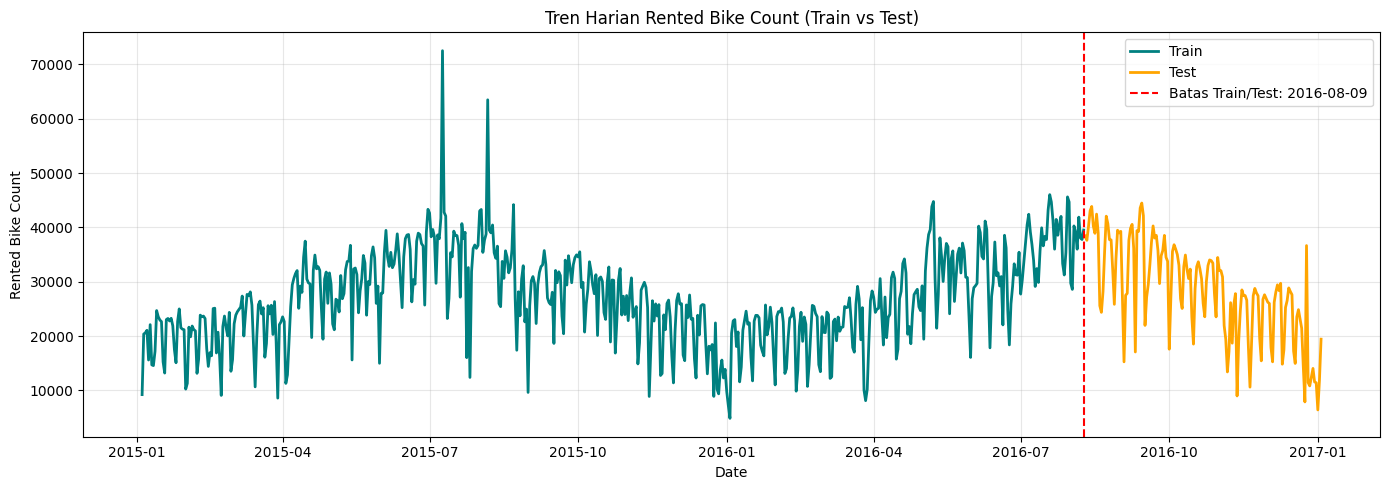

In [14]:
# Grafik time series tren harian dengan pembagian train vs test
split_date = train['ds'].iloc[-1]

plt.figure(figsize=(14, 5))
plt.plot(train['ds'], train['y'], color='teal', linewidth=2, label='Train')
plt.plot(test['ds'], test['y'], color='orange', linewidth=2, label='Test')

plt.axvline(
    x=split_date,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Batas Train/Test: {split_date.date()}'
)

plt.title('Tren Harian Rented Bike Count (Train vs Test)')
plt.xlabel('Date')
plt.ylabel('Rented Bike Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Variabel Holidays

In [15]:
import holidays

In [16]:
# ambil tahun dari data
years = df['ds'].dt.year.unique()

# ambil holiday untuk Great Britain dan buat DataFrame
gb_holidays = holidays.GB(years=years)
holidays_df = pd.DataFrame(list(gb_holidays.items()), columns=['ds', 'holiday'])
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

print("Holidays DataFrame dengan window:")                                                      
print(holidays_df.head(10))

Holidays DataFrame dengan window:
          ds                   holiday
0 2016-03-25               Good Friday
1 2016-05-02                   May Day
2 2016-05-30       Spring Bank Holiday
3 2016-01-01            New Year's Day
4 2016-12-25             Christmas Day
5 2016-12-27  Christmas Day (observed)
6 2016-12-26                Boxing Day
7 2017-04-14               Good Friday
8 2017-05-01                   May Day
9 2017-05-29       Spring Bank Holiday


## Training Model

In [17]:
m = Prophet(
    holidays=holidays_df,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=1,
    holidays_prior_scale=10,
    seasonality_mode='multiplicative'
)
m.fit(train)

01:31:02 - cmdstanpy - INFO - Chain [1] start processing
01:31:04 - cmdstanpy - INFO - Chain [1] done processing


## Forecast Pada Test

In [18]:
forecast_test = m.predict(test[['ds']])

print(forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

          ds          yhat    yhat_lower    yhat_upper
0 2016-08-10  38271.559368  31528.141446  44405.679992
1 2016-08-11  38550.580867  31693.567399  44598.201692
2 2016-08-12  36547.572966  29857.418068  42943.260054
3 2016-08-13  32141.624388  26040.373397  38748.009310
4 2016-08-14  30391.319973  24074.177306  36754.467812


## Evaluasi Metrik

In [19]:
# Evaluasi metrics pada test set
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### Test

In [20]:
# Gabungkan forecast dengan actual
test_with_forecast = test.copy()
test_with_forecast['yhat'] = forecast_test['yhat'].values

# Hitung metrics
mae = mean_absolute_error(test_with_forecast['y'], test_with_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_with_forecast['y'], test_with_forecast['yhat']))
mape = np.mean(np.abs((test_with_forecast['y'] - test_with_forecast['yhat']) / test_with_forecast['y'])) * 100

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE: 5039.81
RMSE: 6110.38
MAPE: 18.76%


### Train

In [21]:
# Evaluasi metrics pada train set
forecast_train = m.predict(train[['ds']])

train_with_forecast = train.copy()
train_with_forecast['yhat'] = forecast_train['yhat'].values

mae_train = mean_absolute_error(train_with_forecast['y'], train_with_forecast['yhat'])
rmse_train = np.sqrt(mean_squared_error(train_with_forecast['y'], train_with_forecast['yhat']))

# aman jika ada nilai y = 0
mape_train = np.mean(
    np.abs((train_with_forecast['y'] - train_with_forecast['yhat']) / (train_with_forecast['y'] + 1e-8))
) * 100

print(f'Train MAE: {mae_train:.2f}')
print(f'Train RMSE: {rmse_train:.2f}')
print(f'Train MAPE: {mape_train:.2f}%')

Train MAE: 3648.32
Train RMSE: 5061.37
Train MAPE: 16.11%


In [26]:
eval_df = pd.DataFrame({
    'split': ['train', 'test'],
    'MAE': [mae_train, mae],
    'RMSE': [rmse_train, rmse],
    'MAPE (%)': [mape_train, mape]
})
print(eval_df)

   split          MAE         RMSE   MAPE (%)
0  train  3648.320665  5061.372222  16.113674
1   test  5039.807655  6110.383558  18.760236


## Plot Forecast

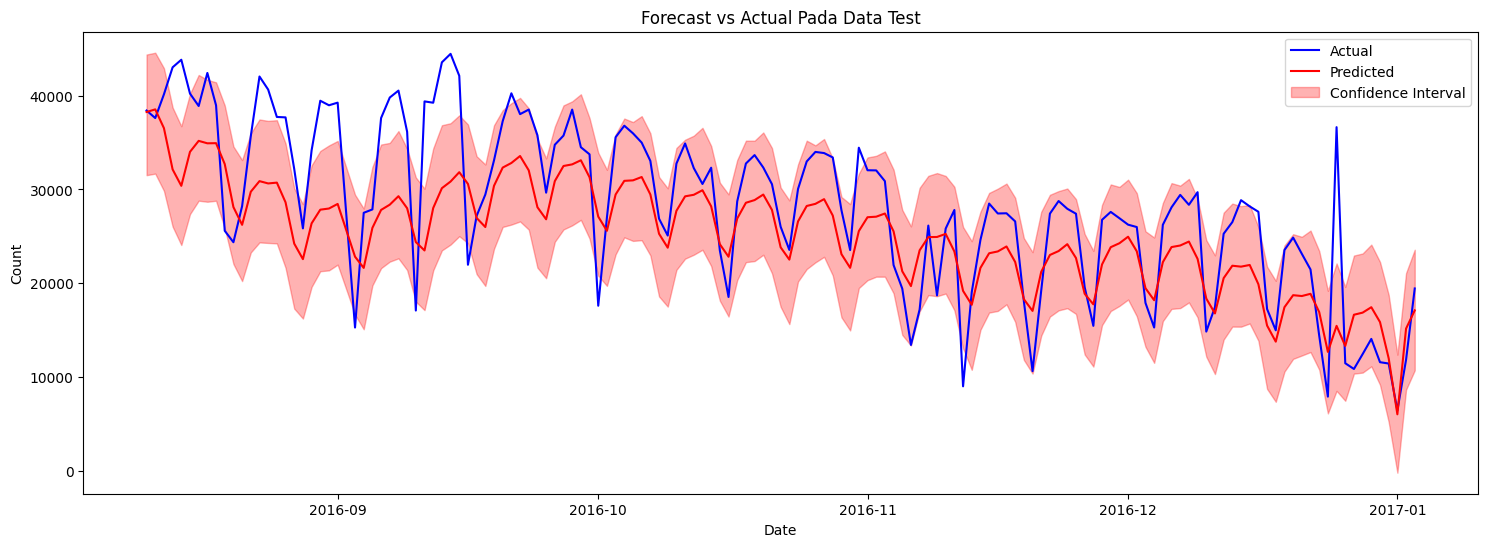

In [22]:
# Plot forecast vs actual
plt.figure(figsize=(18, 6))
plt.plot(test['ds'], test['y'], label='Actual', color='blue')
plt.plot(test['ds'], forecast_test['yhat'], label='Predicted', color='red')
plt.fill_between(test['ds'], forecast_test['yhat_lower'], forecast_test['yhat_upper'], color='red', alpha=0.3, label='Confidence Interval')
plt.title('Forecast vs Actual Pada Data Test')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()

## Komponen

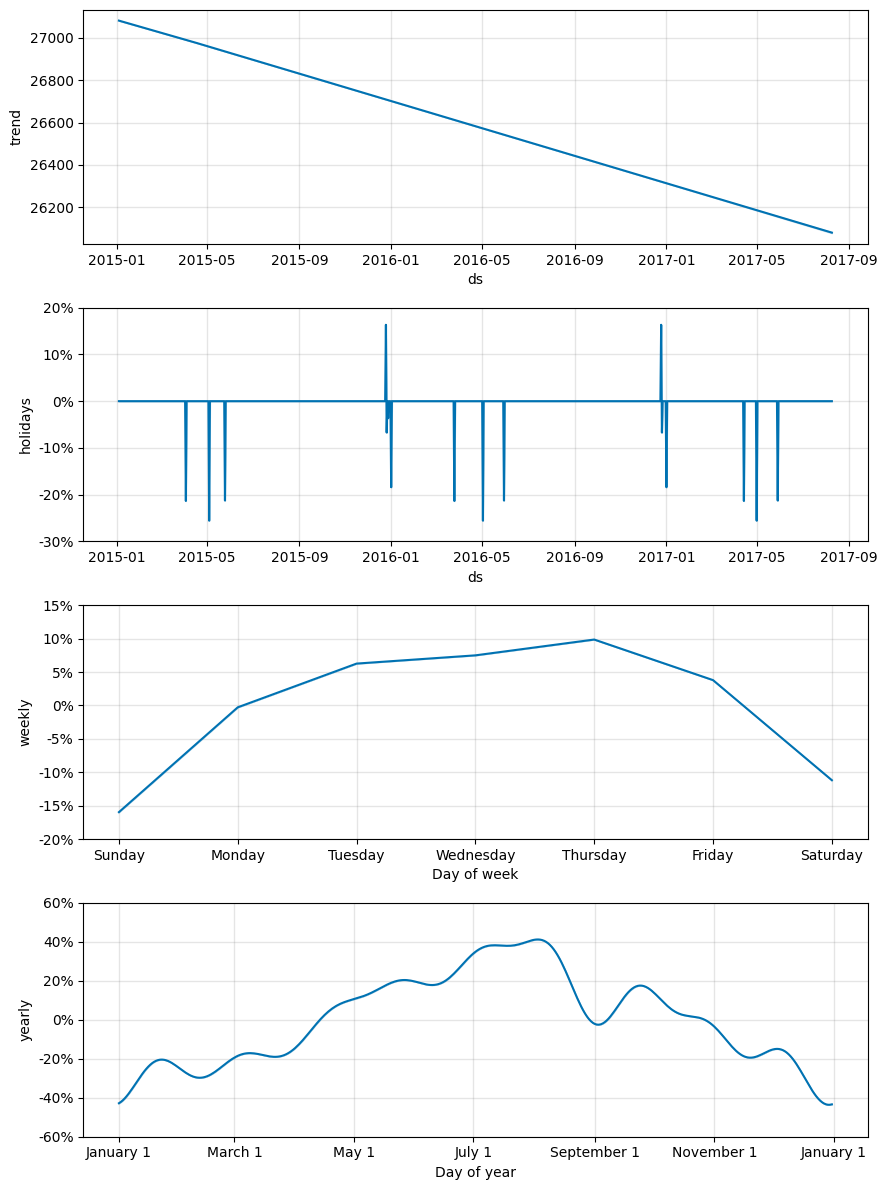

In [23]:
# Buat future dataframe untuk visualisasi komponen
future = m.make_future_dataframe(periods=365, freq='D')  # 1 tahun ke depan
forecast = m.predict(future)

# Plot komponen
fig = m.plot_components(forecast)
plt.show()

## Summary Model

In [24]:
# Tampilkan parameter model Prophet
print("Model Prophet Parameters:")
print(m.params)

Model Prophet Parameters:
OrderedDict([('lp__', array([[1262.5298]])), ('k', array([[-0.00816678]])), ('m', array([[0.37351365]])), ('delta', array([[-8.4426469e-07, -3.7753742e-08,  4.3069468e-09, -9.8264894e-06,
        -3.4224607e-04, -4.3945406e-08,  1.9241614e-08, -1.4015234e-07,
        -7.5770070e-08, -1.4245968e-08,  6.4778547e-10,  3.3000570e-08,
         1.2059597e-08, -5.8831874e-08,  2.6708794e-08, -3.7040971e-09,
        -3.7979034e-08, -1.7855152e-08,  3.0925795e-08, -1.7118510e-07,
        -1.3400400e-08, -5.8886108e-09, -4.6453871e-08,  1.0072095e-08,
         9.7723024e-09]])), ('sigma_obs', array([[0.0696822]])), ('beta', array([[-0.07287812, -0.30031964, -0.00940118,  0.0118815 , -0.00350449,
        -0.03265252,  0.05464876, -0.00395368, -0.04051665, -0.00249758,
         0.01117863, -0.03525586,  0.02779059, -0.00920074, -0.00404809,
        -0.01565146,  0.00340172, -0.04590131,  0.01323093,  0.00400141,
        -0.07635598,  0.09324829,  0.04635205,  0.00473434, 

In [25]:
# Tampilkan info model
print("Prophet Model Summary:")
print(f"Growth: {m.growth}")
print(f"Seasonality Mode: {m.seasonality_mode}")
print(f"Changepoint Prior Scale: {m.changepoint_prior_scale}")
print(f"Seasonality Prior Scale: {m.seasonality_prior_scale}")
print(f"Holidays Prior Scale: {m.holidays_prior_scale}")

Prophet Model Summary:
Growth: linear
Seasonality Mode: multiplicative
Changepoint Prior Scale: 0.1
Seasonality Prior Scale: 1.0
Holidays Prior Scale: 10.0
